# SPARC Pipeline Demo

This notebook demonstrates the basic usage of the SPARC (Spectral Pattern Analysis for ROI Classification) pipeline. 

**Prerequisites:**
1. Ensure you have downloaded the SAM model weights (`sam_vit_h_4b8939.pth`).
2. Ensure you have the required external repositories installed (`asdf`, `pdr`, etc.).
3. Set the `IOF_DATA_PATH` variable below to point to your data directory.

In [1]:
import sys
import logging
from pathlib import Path

# Import SPARC
from src.sparc import Sparc, export_spectra_csv, configure_logging

# Configure logging to see detailed progress
configure_logging(verbose=True)

e:\projects\sparc\.venv\Lib\site-packages\fs\__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore


In [2]:
# === CONFIGURE THESE PATHS ===
SOL = "0613"  # Good for showing GMM: "0920", 0
IOF_DATA_PATH = f"e:/products/{SOL}/iof"
SAM_MODEL_PATH = "C:\\Users\\Lars\\Documents\\Python\\mars_lab\\models\\sam_vit_h_4b8939.pth"

OBS_IX = 3

print(f"IOF Path: {IOF_DATA_PATH}")
print(f"SAM Model: {SAM_MODEL_PATH}")

IOF Path: e:/products/0613/iof
SAM Model: C:\Users\Lars\Documents\Python\mars_lab\models\sam_vit_h_4b8939.pth


## 1. Initialize Pipeline

We initialize the `Sparc` class with the path to the SAM model. We enable GPU acceleration and threading for performance.

In [3]:
sparc = Sparc(
    sam_model_path=SAM_MODEL_PATH,
    use_gpu=True,       # Will fall back to CPU if CUDA is not available
    use_threading=True, # Enables parallel ROI extraction
    verbose=True        # Print debug stats
)

13:53:19 - src.sparc.core.sparc - DEBUG - SPARC initialized with verbose logging enabled


## 2. Run Processing Steps

We can chain the methods together to run the full pipeline. 

* **Load:** Reads IOF data and aligns stereo cameras.
* **Preprocess:** Masks shadows/sky and converts to R*.
* **Segment:** Uses SAM to find semantic regions.
* **Extract ROIs:** Sub-clusters segments to find homogeneous spectral regions.
* **Analyze:** Detects outliers and clusters spectra.
* **Select:** Picks the best representative ROI for each cluster.

In [4]:
(
    sparc
    .load(
        iof_path=IOF_DATA_PATH, 
        seq_id=None,  # might need 
        obs_ix=OBS_IX
    )
    .preprocess(
        apply_r_star=True,
        skymask_kwargs={'percentile': 0.50}
    )
    .segment(
        preserve_background=True,
        points_per_side=32,   # Higher = more detailed segmentation
        pred_iou_thresh=0.88
    )
    .extract_rois(
        area_threshold=50,       # Minimum ROI size in pixels
        min_cluster_area=500,    # Min segment size to attempt sub-clustering
        min_clean_area=4000      # Min size after cleaning artifacts
    )
    .analyze(
        contamination=0.10,    # Estimated % of outliers in data
        max_components=None   # Auto-detect number of spectral clusters
    )
    .select()                 # Final heuristic selection
)

13:53:19 - src.sparc.core.pipeline - INFO - Loading ZCAM data from e:/products/0613/iof
13:53:28 - src.sparc.core.pipeline - INFO - Loaded scene: SOL0613_zcam03483_RSM596
13:53:28 - src.sparc.core.pipeline - DEBUG - Load took 9.21s | cube shape: (14, 1178, 1598)
13:53:28 - src.sparc.core.pipeline - DEBUG - Wavelengths: [480.0, 544.0, 630.0, 800.0, 754.0, 677.0, 605.0, 528.0, 442.0, 866.0, 910.0, 939.0, 978.0, 1022.0]
13:53:28 - src.sparc.core.pipeline - INFO - Preprocessing - masking and photometric calibration
13:53:33 - src.sparc.core.pipeline - DEBUG - Shadow=9.8%  Sky=0.0%  Valid=85.0%
13:53:33 - src.sparc.core.pipeline - DEBUG - R* range: [0.000, 1.427]  mean: 0.334
13:53:33 - src.sparc.core.pipeline - DEBUG - Preprocessing took 5.26s
13:53:33 - src.sparc.core.pipeline - INFO - Segmenting with gpu
13:53:50 - src.sparc.core.pipeline - INFO - Found 118 segments in 16.72s
13:53:50 - src.sparc.core.pipeline - INFO - Extracting ROIs with threaded
13:53:57 - src.sparc.core.pipeline - IN

## 3. Visualization

Plot the summary of the run, showing the segmentation map, the final selected ROIs, and their corresponding spectra.

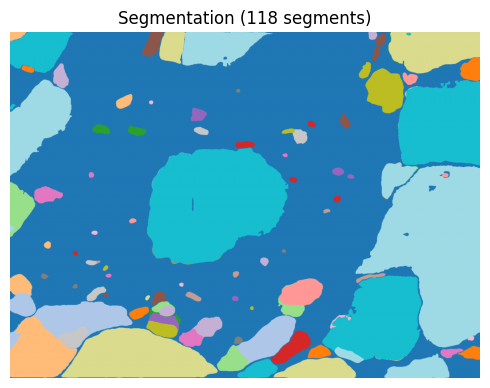

In [5]:
sparc.plot(show_segments=True, show_rois=False, show_spectra=False, figsize=(5, 5))

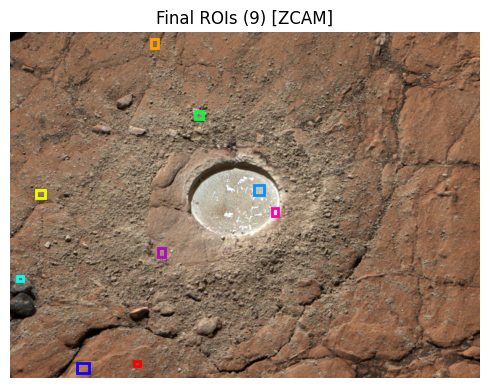

In [6]:
sparc.plot(show_segments=False, show_rois=True, show_spectra=False, figsize=(5, 5))

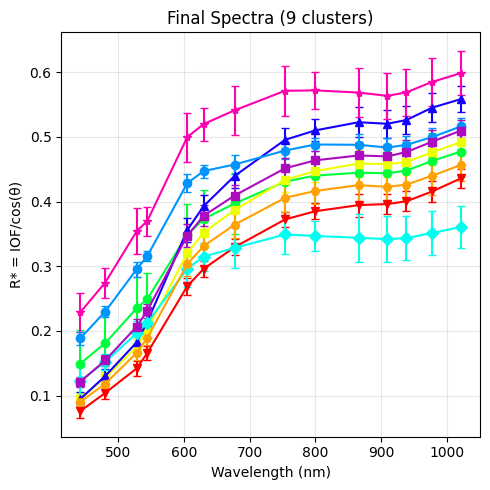

In [7]:
sparc.plot(show_segments=False, show_rois=False, show_spectra=True, figsize=(5, 5))

## 4. Accessing Data Programmatically

You can access the raw data directly from the result object.

In [8]:
result = sparc.result

print(f"Scene ID: {result.scene_id}")
print(f"Number of final ROIs: {len(result.final_rois)}")
print(f"Number of spectral clusters: {result.n_clusters}")

# Example: Print coordinates of the first ROI
if len(result.final_rois) > 0:
    x, y, w, h = result.final_rois[0]
    print(f"First ROI: x={x}, y={y}, w={w}, h={h}")

Scene ID: SOL0613_zcam03483_RSM596
Number of final ROIs: 9
Number of spectral clusters: 9
First ROI: x=630, y=269, w=27, h=27
